<a href="https://colab.research.google.com/github/devMoamen/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Prediction of Product Sales
- Author: Moamen ayyad

## Project Overview

## Load and Inspect Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Loading dataset from google drive
sales_df = pd.read_csv('/content/drive/MyDrive/ds_course/sales_predictions_2023.csv')

In [5]:
#Explore first 5 row of dataframe
sales_df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [6]:
#Explore the summery of dataframe
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## Clean Data

In [7]:
#check duplicated
sales_df.duplicated().sum()

np.int64(0)

In [8]:
#Check missing values
sales_df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [9]:
sales_df['Item_Weight'] = sales_df['Item_Weight'].fillna(-1)
sales_df['Outlet_Size'] = sales_df['Outlet_Size'].fillna('Missing')

In [10]:
#To be sure there is no missing values
sales_df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [11]:
#1) Check each categories column's value counts for inconsistent values.
object_columns = sales_df.select_dtypes(include=['object']).columns
for column in object_columns:
    print(sales_df[column].value_counts())

Item_Identifier
FDW13    10
FDG33    10
FDX31     9
FDT07     9
NCY18     9
         ..
FDO33     1
FDK57     1
FDT35     1
FDN52     1
FDE52     1
Name: count, Length: 1559, dtype: int64
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
Outlet_Identifier
OUT027    935
OUT013    932
OUT035    930
OUT049    930
OUT046    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: count, dt

In [12]:
#Dealing with inconsistancy in Item_Fat_Content column
sales_df['Item_Fat_Content'] = sales_df['Item_Fat_Content'].replace('LF','Low Fat')
sales_df['Item_Fat_Content'] = sales_df['Item_Fat_Content'].replace('low fat','Low Fat')
sales_df['Item_Fat_Content'] = sales_df['Item_Fat_Content'].replace('reg','Regular')
#4) Display the value_counts again to confirm the values are now consistent.
sales_df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [13]:
#Describe all columns in dataframe
sales_df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,10.478936,0.066132,140.992782,1997.831867,2181.288914
std,6.720742,0.051598,62.275067,8.371760,1706.499616
min,-1.000000,0.000000,31.290000,1985.000000,33.290000
25%,6.650000,0.026989,93.826500,1987.000000,834.247400
50%,11.000000,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


## Exploratory Data Analysis

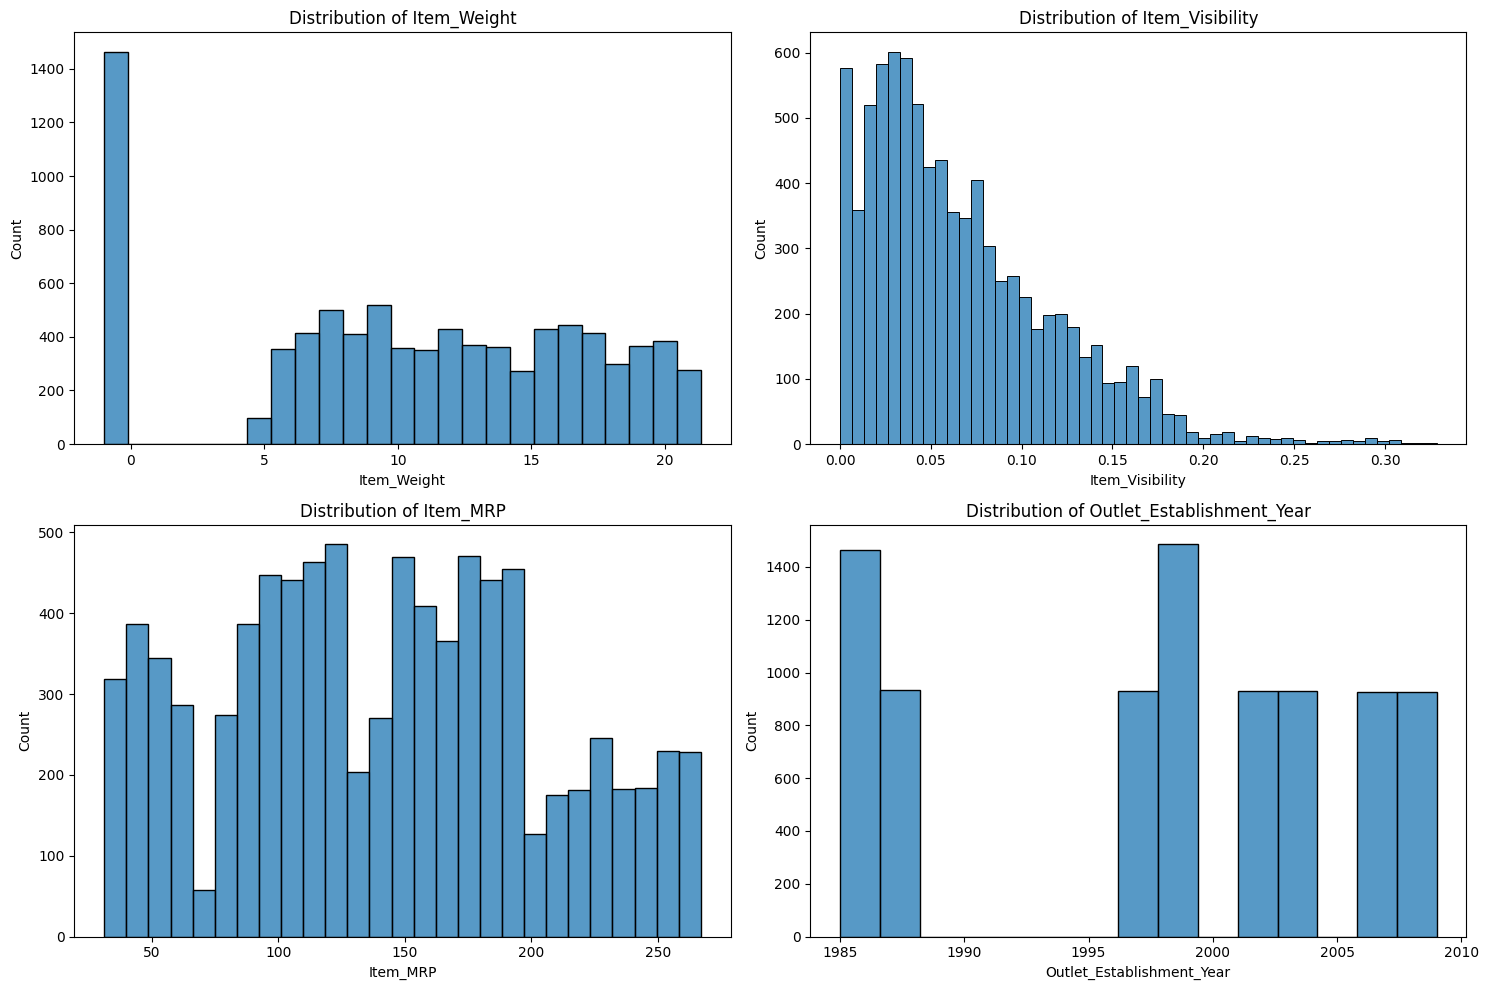

In [14]:
#Histograms to view the distributions of numerical features in your dataset.

# Identify numerical columns
num_cols = sales_df.drop(columns=['Item_Outlet_Sales']).select_dtypes('number').columns
n_cols = 2
n_rows = (len(num_cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=sales_df, x=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()


### Numerical Distribution Summary

Based on the histograms generated:

1. **Item_Weight**: The spike at -1 is due to our previous imputation of missing values. Otherwise, the weight is distributed fairly evenly across different ranges.
2. **Item_Visibility**: This feature is **Right-Skewed**, meaning most items have low visibility, while only a few items are highly visible in the store.
3. **Item_MRP**: The Maximum Retail Price shows a multimodality (multiple peaks), suggesting that products might be grouped into different price tiers.
4. **Outlet_Establishment_Year**: Shows peaks corresponding to specific years when new stores were opened, with a significant amount of data from the mid-80s and late 90s/2000s.

Text(0.5, 1.0, 'Correlation Heatmap of Features')

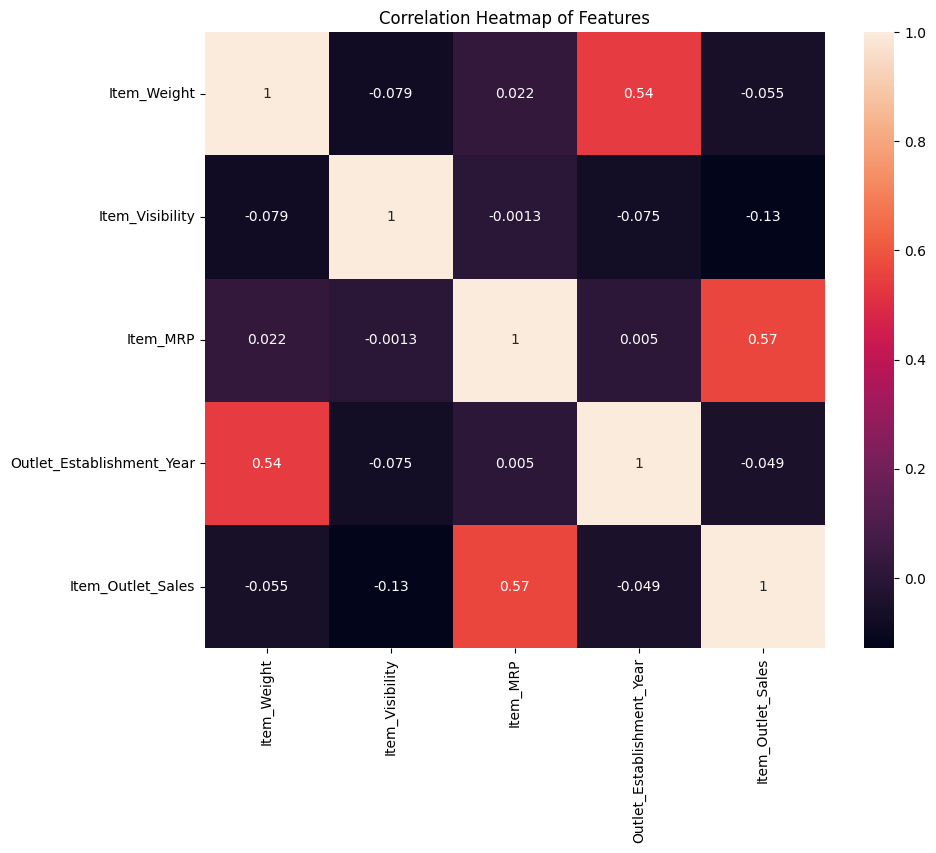

In [15]:
#Heatmap to view the correlation between features.

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(sales_df.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap of Features')

### Correlation Analysis Summary

The correlation heatmap provides several insights into the relationships between features:

1. **Strongest Positive Correlation**: `Item_MRP` (Maximum Retail Price) has a strong positive correlation with `Item_Outlet_Sales` (approx. 0.57). This suggests that as the price of an item increases, the total sales value for that item also tends to increase.
2. **Outlet Establishment Year**: There is a moderate correlation between `Outlet_Establishment_Year` and `Item_Weight` in this specific imputed dataset, likely due to how missing values were handled or the distribution of items across different store ages.
3. **Item Visibility**: `Item_Visibility` shows a slight negative correlation with sales, which is counter-intuitive but common in this dataset, possibly suggesting that highly visible items aren't always the top sellers.
4. **Weak Correlations**: Many features show very low correlation with each other (near 0), indicating they provide independent information for potential machine learning models.

## Feature Inspection

In [18]:
#Remove the placeholders you added in week 2 and replace them with null values.
sales_df = sales_df.replace({'Item_Weight': -1, 'Outlet_Size': 'Missing'}, np.nan)
sales_df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [22]:
def explore_categorical(df, x, fillna = True, placeholder = 'MISSING',
                        figsize = (6,4), order = None):

  # Make a copy of the dataframe and fillna
  temp_df = df.copy()
  # Before filling nulls, save null value counts and percent for printing
  null_count = temp_df[x].isna().sum()
  null_perc = null_count/len(temp_df)* 100
  # fillna with placeholder
  if fillna == True:
    temp_df[x] = temp_df[x].fillna(placeholder)
  # Create figure with desired figsize
  fig, ax = plt.subplots(figsize=figsize)
  # Plotting a count plot
  sns.countplot(data=temp_df, x=x, ax=ax, order=order)
  # Rotate Tick Labels for long names
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
  # Add a title with the feature name included
  ax.set_title(f"Column: {x}")

  # Fix layout and show plot (before print statements)
  fig.tight_layout()
  plt.show()

  # Print null value info
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")
  # Print cardinality info
  nunique = temp_df[x].nunique()
  print(f"- Unique Values: {nunique}")
  # First find value counts of feature
  val_counts = temp_df[x].value_counts(dropna=False)
  # Define the most common value
  most_common_val = val_counts.index[0]
  # Define the frequency of the most common value
  freq = val_counts.values[0]
  # Calculate the percentage of the most common value
  perc_most_common = freq / len(temp_df) * 100
  # Print the results
  print(f"- Most common value: '{most_common_val}' occurs {freq} times ({round(perc_most_common,2)}%)")
  # print message if quasi-constant or constant (most common val more than 98% of data)
  if perc_most_common > 98:
    print(f"\n- [!] Warning: '{x}' is a constant or quasi-constant feature and should be dropped.")
  else:
    print("- Not constant or quasi-constant.")
  return fig, ax

In [24]:
def explore_numeric(df, x, figsize=(6,5) ):
  # Making our figure with gridspec for subplots
  gridspec = {'height_ratios':[0.7,0.3]}
  fig, axes = plt.subplots(nrows=2, figsize=figsize,
                           sharex=True, gridspec_kw=gridspec)
  # Histogram on Top
  sns.histplot(data=df, x=x, ax=axes[0])
  # Boxplot on Bottom
  sns.boxplot(data=df, x=x, ax=axes[1])
  ## Adding a title
  axes[0].set_title(f"Column: {x}")
  ## Adjusting subplots to best fill Figure
  fig.tight_layout()

  # Ensure plot is shown before message
  plt.show()
  ## Print message with info on the count and % of null values
  null_count = df[x].isna().sum()
  null_perc = null_count/len(df)* 100
  print("")
  print(f"- NaN's Found: {null_count} ({round(null_perc,2)}%)")

# Weight of product

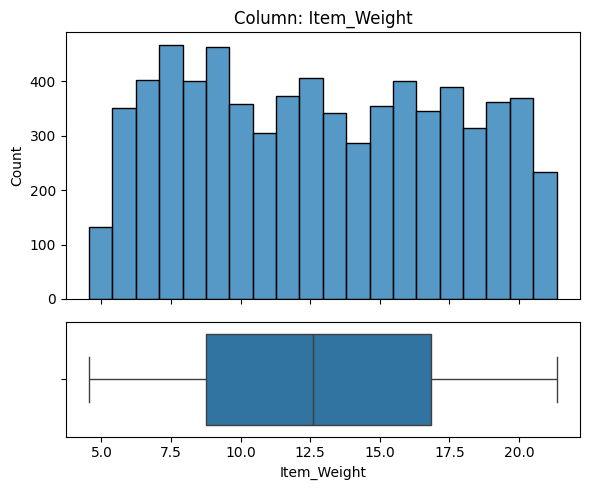


- NaN's Found: 1463 (17.17%)


In [29]:
explore_numeric(sales_df, 'Item_Weight')

In [31]:
print(f'Cardinality of Item_Weight: {sales_df['Item_Weight'].nunique()}')

Cardinality of Item_Weight: 415


### Summary: Item_Weight Analysis

- **Feature Type**: `Item_Weight` is a continuous numerical feature representing a physical attribute of the product.
- **Missing Data**: Approximately 17.17% (1,463 rows) of the data is missing. Given the volume, these should be handled via imputation (mean or median) rather than deletion.
- **Feature Quality**: With a cardinality of 415 unique values, it is not a constant or quasi-constant feature and provides good variance for modeling.
- **Predictor Validity**: Since weight is determined at the time of inventory and listing, it is a valid independent variable that does not cause data leakage for predicting future sales.